## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as albu

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import AdamW, Adam
from torch.optim.lr_scheduler import StepLR
from torch.cuda.amp import GradScaler, autocast

from sklearn.metrics import f1_score
from transformers import AutoModel, AutoProcessor

import random
from IPython.display import display, Image as IPImage
from skimage import feature

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Prepare The Pretrained CLIP

I have chosen the DFN5B-CLIP-ViT-H-14-378 as the pre-trained CLIP model. The Hugging Face link is as follows:

[The Hugging Face link for DFN5B-CLIP-ViT-H-14-378](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378)

In [2]:
# pretrained CLIP 
clip_model = AutoModel.from_pretrained("apple/DFN5B-CLIP-ViT-H-14-378")
processor = AutoProcessor.from_pretrained("apple/DFN5B-CLIP-ViT-H-14-378")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

## Prepare The Datasets

In [3]:
# prepare dataset

data_dir_head = os.path.join("/", "kaggle", "input", "ai-vs-human-generated-dataset")
df_dir_train = os.path.join("/", "kaggle", "input", "ai-vs-human-generated-dataset", "train.csv")
df_dir_test = os.path.join("/", "kaggle", "input", "ai-vs-human-generated-dataset", "test.csv")

class MyDataset(Dataset):
    def __init__(self, df_dir, data_dir, transforms=None, processors=None, is_train=True):
        """
        Args:
            df_dir (str): Directory of the DataFrame containing file names and labels.
            data_dir (str): Directory where the datas are stored.
            transforms (albu.Compose, optional): Albumentations transforms to apply to the images.
            processors (CLIPProcessor): CLIP processors to apply to the images.
            is_train (bool, optional): Flag to indicate if the dataset is for training.
        """      
        xy = pd.read_csv(df_dir)
        self.len = xy.shape[0]
        self.transforms = transforms
        self.processors = processors
        self.is_train = is_train
        self.data_dir = data_dir

        if is_train:
            self.x_array = xy.iloc[:, 1].values
            y_array = xy.iloc[:, -1].values.astype(int)
            self.y_data = torch.from_numpy(y_array).long()
        else:
            self.x_array = xy.iloc[:, 0].values
            self.y_data = xy.iloc[:, 0].values

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        # Load the image
        img_path = os.path.join(self.data_dir, self.x_array[idx])
        image = Image.open(img_path).convert('RGB')

        # Apply transforms if specified
        if self.transforms:
            image = np.array(image)
            image = self.transforms(image=image)['image']
            image = Image.fromarray(image)

        result_list = []
        img_list = [image]

        for i in img_list:
            result_list.append(processor(images=i, return_tensors="pt")['pixel_values'].squeeze(0))

        result = torch.cat(result_list, dim=0)
        
        # train: image, label
        # test:  image, name(str)
        return result, self.y_data[idx]

## Data Augmentation

In [4]:
train_transform = albu.Compose([
    albu.HorizontalFlip(p=0.5),
    albu.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    albu.GaussianBlur(blur_limit=(7, 15), sigma_limit=(1.0, 2.0), always_apply=False, p=0.3),
    albu.Affine(rotate=15, translate_percent=0.1, scale=(0.9, 1.1), shear=10, p=0.1),
    albu.ToGray(p=0.2),
])

val_transform = albu.Compose([
])

Apply data augmentation methods to the dataset.

In [5]:
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_TEST = 64

# get datasets
train_set = MyDataset(df_dir=df_dir_train, data_dir=data_dir_head, transforms=train_transform, processors=processor, is_train=True)

train_size = int(0.998 * len(train_set))
val_size = len(train_set) - train_size

tmp_set, val_set = random_split(train_set, [train_size, val_size])

test_set = MyDataset(df_dir=df_dir_test, data_dir=data_dir_head, transforms=val_transform, processors=processor, is_train=False)

# get loaders
train_loader = DataLoader(dataset = train_set,
                          batch_size = BATCH_SIZE_TRAIN,
                          shuffle = True,
                          num_workers = 4,
                          pin_memory = True,)

val_loader = DataLoader(dataset = val_set,
                        batch_size = BATCH_SIZE_TEST,
                        shuffle = False,
                        num_workers = 4,
                        pin_memory = True)

test_loader = DataLoader(dataset = test_set,
                         batch_size = BATCH_SIZE_TEST,
                         shuffle = False,
                         num_workers = 4,
                         pin_memory = True)

## Model

In [6]:
# check GPU
print('cuda: ', torch.cuda.is_available())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = xm.xla_device()

class CLIPBasedClassifier(nn.Module):
    def __init__(self, clip_model, num_classes=2, freeze_clip=True, clip_hidden_size=1024):
        super(CLIPBasedClassifier, self).__init__()
        self.clip_model = clip_model
        if freeze_clip:
            for param in self.clip_model.parameters():
                param.requires_grad = False
        
        self.clip_output_dim = clip_hidden_size

        self.fc1 = nn.Linear(self.clip_output_dim, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

         # Transformer Block
        self.transformer_block = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=4,
            dim_feedforward=512,
            dropout=0.2
        )

        self.transformer_block_1 = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2
        )
    
    def forward(self, inputs):
        
        image = {'pixel_values': inputs}
        
        with torch.no_grad():
            image_features = self.clip_model.get_image_features(**image)
        
        x = self.fc1(image_features)
        x = self.relu(x)
        x = self.dropout(x)

        # Transformer : (seq_length, batch_size, embed_dim)
        x = x.unsqueeze(0)  # add seq_length
        x = self.transformer_block(x)
        x = x.squeeze(0)  # remove seq_length
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Transformer : (seq_length, batch_size, embed_dim)
        x = x.unsqueeze(0)  # add seq_length
        x = self.transformer_block_1(x)
        x = x.squeeze(0)  # remove seq_length

        x = self.fc3(x)
        
        return x

model = CLIPBasedClassifier(clip_model=clip_model, num_classes=2, freeze_clip=True, clip_hidden_size=1024)

# The model parameters from the last training session
LOAD_MODEL = False
model_path = os.path.join("/", "kaggle", "input", "my-model-for-ai-image-detect", "pytorch", "new_structure", "3", "temp_model.pth")

# check about the model
if LOAD_MODEL and os.path.exists(model_path):
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)
    print("Loaded model from disk.")
else:
    print("Initialized model with random weights.")

model = model.to(device)

cuda:  True
Initialized model with random weights.


In [7]:
LR = 1e-3

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = StepLR(optimizer, step_size=20, gamma=0.45)
loss_fn = nn.CrossEntropyLoss()

## Train

<timed exec>:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
Training Epoch 1:   0%|          | 5/1250 [00:58<3:40:38, 10.63s/it]

[1, 5] loss: 0.68420791625977


Training Epoch 1:   1%|          | 10/1250 [01:47<3:25:26,  9.94s/it]

[1, 10] loss: 0.37571897506714


Training Epoch 1:   1%|          | 15/1250 [02:36<3:22:26,  9.84s/it]

...

[1, 130] loss: 0.16678563356400
count now:  15


Training Epoch 1:  11%|█         | 135/1250 [22:12<3:02:09,  9.80s/it]

[1, 135] loss: 0.10583921670914


Training Epoch 1:  11%|█         | 139/1250 [23:01<3:03:59,  9.94s/it]
<timed exec>:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


[1, 140] loss: 0.12770950794220
count now:  16
patience break


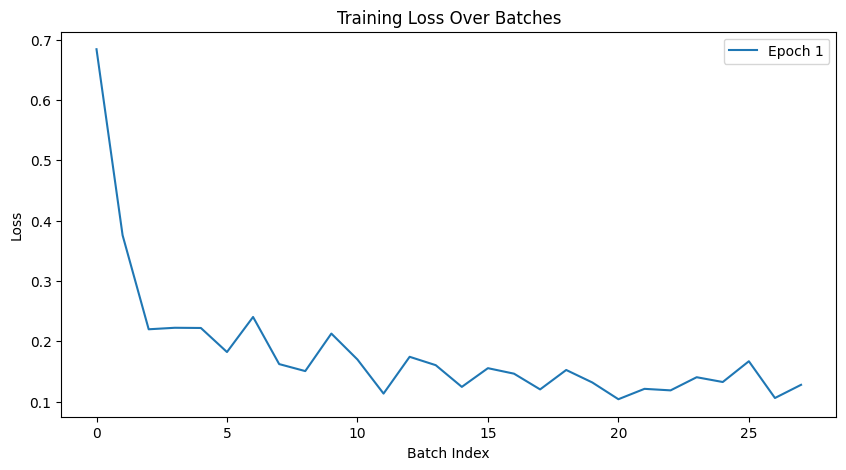

Testing: 100%|██████████| 3/3 [00:27<00:00,  9.05s/it]

F1 score on test set: 0.9563
New best model saved with F1 score: 0.9563
CPU times: user 21min 42s, sys: 1min 43s, total: 23min 26s
Wall time: 23min 28s


In [8]:
%%time

# The maximum F1 score from the last training session.
best_f1_score = 0.0
NUM_EPOCH = 1
scaler = GradScaler()

def train(epoch, patience=15):
    """
    Args:
        epoch (int): The current epoch number.
        patience (int): The threshold parameter for controlling early stopping.
    """
    model.train()
    running_loss = 0.0
    loss_list = []
    count = 0

    min_loss_so_far = 100.0
    
    for batch_idx, data in enumerate(tqdm(train_loader, desc=f'Training Epoch {epoch + 1}'), 0):
        inputs, target = data
        inputs, target = inputs.to(device), target.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = loss_fn(outputs, target)
        
        # print(outputs)
        # print(target)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        scheduler.step()

        if batch_idx % 5 == 4:
            tqdm.write(f'[{epoch + 1}, {batch_idx + 1}] loss: {running_loss / 5:.14f}')
            min_loss = min(loss_list[-5:]) if len(loss_list) > 5 else 100.0
            loss_list.append(running_loss / 5)

            if running_loss / 5 < min_loss_so_far:
                min_loss_so_far = running_loss / 5
                save_model('temp_model.pth')
            
            running_loss = 0.0

            if len(loss_list) > 0 and loss_list[-1] > min_loss:
                count = count + 1
                print('count now: ', count)
    
            if count > patience:
                print('patience break')
                break
            
            # Increase the minimum recorded loss to discard model parameters that are too outdated.
            min_loss_so_far = min_loss_so_far + 0.002

        # break # if no more train

    state_dict = torch.load('temp_model.pth')
    model.load_state_dict(state_dict, strict=False)
    
    plt.figure(figsize=(10, 5))
    plt.plot(loss_list, label=f'Epoch {epoch + 1}')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Batches')
    plt.legend()
    plt.show() 

def evaluate():
    model.eval()
    global best_f1_score
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for data in tqdm(val_loader, desc='Testing'):
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
            # break # if no more test

    f1 = f1_score(all_labels, all_predictions, average='weighted')
    print(f'F1 score on test set: {f1:.4f}')

    if f1 > best_f1_score:
        best_f1_score = f1
        save_model('best_model.pth')
        print(f'New best model saved with F1 score: {f1:.4f}')

def save_model(name):
    state_dict = model.state_dict()
    # The parameter of clip is not necessary
    for key in list(state_dict.keys()):
        if key.startswith('clip_model.'):
            del state_dict[key]
    torch.save(state_dict, name)

save_model('best_model.pth')
if NUM_EPOCH <= 0:
    evaluate()

for epoch in range(NUM_EPOCH):
    train(epoch=epoch, patience=15)
    evaluate()

## Prediction

In [9]:
%%time

state_dict = torch.load('best_model.pth')
model.load_state_dict(state_dict, strict=False)
model.to(device)

real_output = []

with torch.no_grad():
    for idx, (images, ids) in enumerate(tqdm(test_loader, total=len(test_loader))):
        images = images.to(device, non_blocking=True)
        
        with autocast():
            outputs = model(images)

        outputs = torch.softmax(outputs, dim=-1)
        prob_class_1 = outputs[:, 1].cpu().numpy()
        
        for id_, prob in zip(ids, prob_class_1):
            real_output.append((id_, prob))
            
        print(f"Progress: {idx}/{len(test_loader)}")

# The file that contains the predicted probabilities
probabilities_df = pd.DataFrame(real_output, columns=["id", "prob_class_1"])
probabilities_csv_path = "probabilities.csv"
probabilities_df.to_csv(probabilities_csv_path, index=False)
print(f"Probabilities file saved at {probabilities_csv_path}")

<timed exec>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  1%|          | 1/87 [00:14<20:49, 14.52s/it]

Progress: 0/87


  2%|▏         | 2/87 [00:24<16:38, 11.75s/it]

Progress: 1/87


  3%|▎         | 3/87 [00:34<15:13, 10.87s/it]

...

Progress: 84/87


 99%|█████████▉| 86/87 [14:07<00:09,  9.79s/it]

Progress: 85/87


100%|██████████| 87/87 [14:12<00:00,  9.80s/it]

Progress: 86/87
Probabilities file saved at probabilities.csv
CPU times: user 14min 8s, sys: 5.05 s, total: 14min 13s
Wall time: 14min 12s


## Get The Submission file

Since the F1 score is $66.570$ when all predictions are $1$ (my code: [The All-Ones Hack for Scores](https://www.kaggle.com/code/gaokui/the-all-ones-hack-for-scores)), we can infer that the test dataset is balanced. Therefore, by obtaining the model's predicted probabilities for each image being classified as $1$, and using the median of these probabilities as the threshold, we can achieve satisfactory results.

I'm not entirely sure if this can be considered a dataset artifact. After all, even if the dataset is imbalanced, we can still determine the threshold through learning. The file `probabilities.csv` records the probabilities output by the model. After the run is completed, you can manually set the threshold to obtain different results.

For reference, if you use the same `probabilities.csv` file as in my best result (the submission that scored $0.9$ on the private leaderboard) and set the threshold to $0.5$, the F1 score would be $0.83$ on public LB, $0.843$ on private LB.

In [10]:
USE_DYNAMIC_THRESHOLD = True

probabilities_df = pd.read_csv(probabilities_csv_path)

if USE_DYNAMIC_THRESHOLD:
    # Calculate the median of the probabilities
    threshold = probabilities_df['prob_class_1'].median()
    print(f"Median probability for class 1: {threshold}")
else:
    threshold = 0.5
    print(f"Threshold: {threshold}")

# Use the median as the threshold to generate the submission.csv
submission_df = probabilities_df.copy()
submission_df['label'] = (submission_df['prob_class_1'] > threshold).astype(int)
submission_csv_path = "submission.csv"
submission_df[['id', 'label']].to_csv(submission_csv_path, index=False)
print(f"Submission file saved at {submission_csv_path}")

Median probability for class 1: 0.01106
Submission file saved at submission.csv


In [11]:
USE_DYNAMIC_THRESHOLD = False

probabilities_df = pd.read_csv(probabilities_csv_path)

if USE_DYNAMIC_THRESHOLD:
    # Calculate the median of the probabilities
    threshold = probabilities_df['prob_class_1'].median()
    print(f"Median probability for class 1: {threshold}")
else:
    threshold = 0.5
    print(f"Threshold: {threshold}")

# Use the median as the threshold to generate the submission.csv
submission_df = probabilities_df.copy()
submission_df['label'] = (submission_df['prob_class_1'] > threshold).astype(int)
submission_csv_path = "submission_normal_threshold.csv"
submission_df[['id', 'label']].to_csv(submission_csv_path, index=False)
print(f"Submission file saved at {submission_csv_path}")

Threshold: 0.5
Submission file saved at submission_normal_threshold.csv
